In [1]:
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline
import MATS
from scipy import stats

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")

HAPI version: 1.2.2.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
from MATS.linelistdata import linelistdata
PARAM_LINELIST = linelistdata['O2_ABand_Drouin_2017_linelist']


PARAM_LINELIST['BIA_slope_air'] = 0.0
PARAM_LINELIST['m transition'] = PARAM_LINELIST['m'].copy()
PARAM_LINELIST.loc[PARAM_LINELIST['m'].notna(), 'BIA_slope_air'] = PARAM_LINELIST[PARAM_LINELIST['m'].notna()]['m'].abs()*-0.01196 + 0.49421
PARAM_LINELIST = PARAM_LINELIST[PARAM_LINELIST['m'].notna()]



In [3]:
wave_range = 1.5 #range outside of experimental x-range to simulate
IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
Fit_Intensity = 1e-26 #intensities must be above this value for the line to be fit
order_baseline_fit = 1
sample_molefraction = {7 :0.002022}
wave_min = 13150 #cm-1
wave_max = 13165 #cm-1
wave_space = 0.005 #cm-1
baseline_terms = [0] #polynomial baseline coefficients where the index is equal to the coefficient order
PARAM_LINELIST = PARAM_LINELIST[(PARAM_LINELIST['nu']<=wave_max) & (PARAM_LINELIST['nu']>=wave_min)]

spec_1 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 200,
                     wing_cutoff = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': True, 'farwing_continuum': None})
spec_2 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 400,
                     wing_cutoff = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': True, 'farwing_continuum': None})
spec_3 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 600,
                     wing_cutoff = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': True, 'farwing_continuum': None})
spec_4 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 800,
                     wing_cutoff = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': True, 'farwing_continuum': None})
spec_5 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 1000,
                     wing_cutoff = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': True, 'farwing_continuum': None})



In [4]:
SPECTRA = MATS.Dataset([spec_1, spec_2, spec_3, spec_4, spec_5], 'Fit_Test', PARAM_LINELIST,  BIA_model = {'sw_depletion': True, 'farwing_continuum': None})  


FITPARAMS = MATS.Generate_FitParam_File(SPECTRA, lineprofile = 'SDNGP', linemixing = True, 
                          fit_intensity = Fit_Intensity, threshold_intensity = IntensityThreshold, sim_window = wave_range,
                          nu_constrain = True, sw_constrain = True, gamma0_constrain = True, delta0_constrain = True, 
                           aw_constrain = True, as_constrain = True, 
                           nuVC_constrain = True, eta_constrain =True, linemixing_constrain = True,
                            additional_columns = ['trans_id', 'local_lower_quanta', 'm transition'])

FITPARAMS.generate_fit_baseline_linelist(vary_baseline = False, vary_molefraction = {7:False, 1:False}, vary_xshift = False, vary_temperature = False, 
                                      vary_etalon_amp= False, vary_etalon_period= False, vary_etalon_phase= False)

FITPARAMS.generate_fit_param_linelist_from_linelist(vary_nu = {7:{1:False, 2:False, 3:False}}, vary_sw = {7:{1:True, 2:False, 3:False}},
                                                    vary_gamma0 = {7:{1: False, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma0 = {7:{1:False}}, 
                                                    vary_delta0 = {7:{1:False , 2:False, 3: False}, 1:{1:False}}, vary_n_delta0 = {7:{1:False}}, 
                                                    vary_aw = {7:{1: False, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma2 = {7:{1:False}}, 
                                                    vary_as = {}, vary_n_delta2 = {7:{1:False}}, 
                                                    vary_nuVC = {7:{1:False, 2:False}}, vary_n_nuVC = {7:{1:False}},
                                                    vary_eta = {}, vary_linemixing = {7:{1:True}})



,trans_id,local_lower_quanta,m transition,molec_id,local_iso_id,elower,nu,nu_err,nu_vary,sw,...,eta_air_err,eta_air_vary,y_air,y_air_err,y_air_vary,n_y_air,BIA_slope_air,BIA_slope_air_err,BIA_slope_air_vary,BIA_collision_duration_air
0,6297222,R 11Q 12 d,13.0,7,1,188.71,13150.20,0.0,False,770.0000,...,0.0,False,-0.000057,0.0,True,1.849878,0.33873,0.0,False,0.0
1,6297223,R 13R 13 d,14.0,7,1,262.58,13151.35,0.0,False,568.0000,...,0.0,False,-0.000350,0.0,True,3.389741,0.32677,0.0,False,0.0
2,6281155,R 43R 43 d,44.0,7,1,2703.84,13151.74,0.0,False,0.0131,...,0.0,False,0.000000,0.0,False,1.000000,-0.03203,0.0,False,0.0
3,6297224,R 13Q 14 d,15.0,7,1,260.50,13153.43,0.0,False,631.0000,...,0.0,False,-0.000510,0.0,True,1.852150,0.31481,0.0,False,0.0
4,6281164,R 43Q 44 d,45.0,7,1,2701.49,13154.09,0.0,False,0.0137,...,0.0,False,0.000000,0.0,False,1.000000,-0.04399,0.0,False,0.0
5,6297225,R 15R 15 d,16.0,7,1,345.85,13154.18,0.0,False,437.0000,...,0.0,False,-0.000860,0.0,True,3.020138,0.30285,0.0,False,0.0
6,6281168,R 41R 41 d,42.0,7,1,2462.41,13154.64,0.0,False,0.0405,...,0.0,False,0.000000,0.0,False,1.000000,-0.00811,0.0,False,0.0
7,6297226,R 15Q 16 d,17.0,7,1,343.75,13156.28,0.0,False,480.0000,...,0.0,False,-0.001030,0.0,True,1.985142,0.29089,0.0,False,0.0
8,6297227,R 17R 17 d,18.0,7,1,440.56,13156.62,0.0,False,312.0000,...,0.0,False,-0.001430,0.0,True,3.137980,0.27893,0.0,False,0.0
9,6281180,R 41Q 42 d,43.0,7,1,2460.08,13156.98,0.0,False,0.0423,...,0.0,False,0.000000,0.0,False,1.000000,-0.02007,0.0,False,0.0


In [5]:
SPECTRA.BIA_model

{'sw_depletion': True, 'farwing_continuum': None}

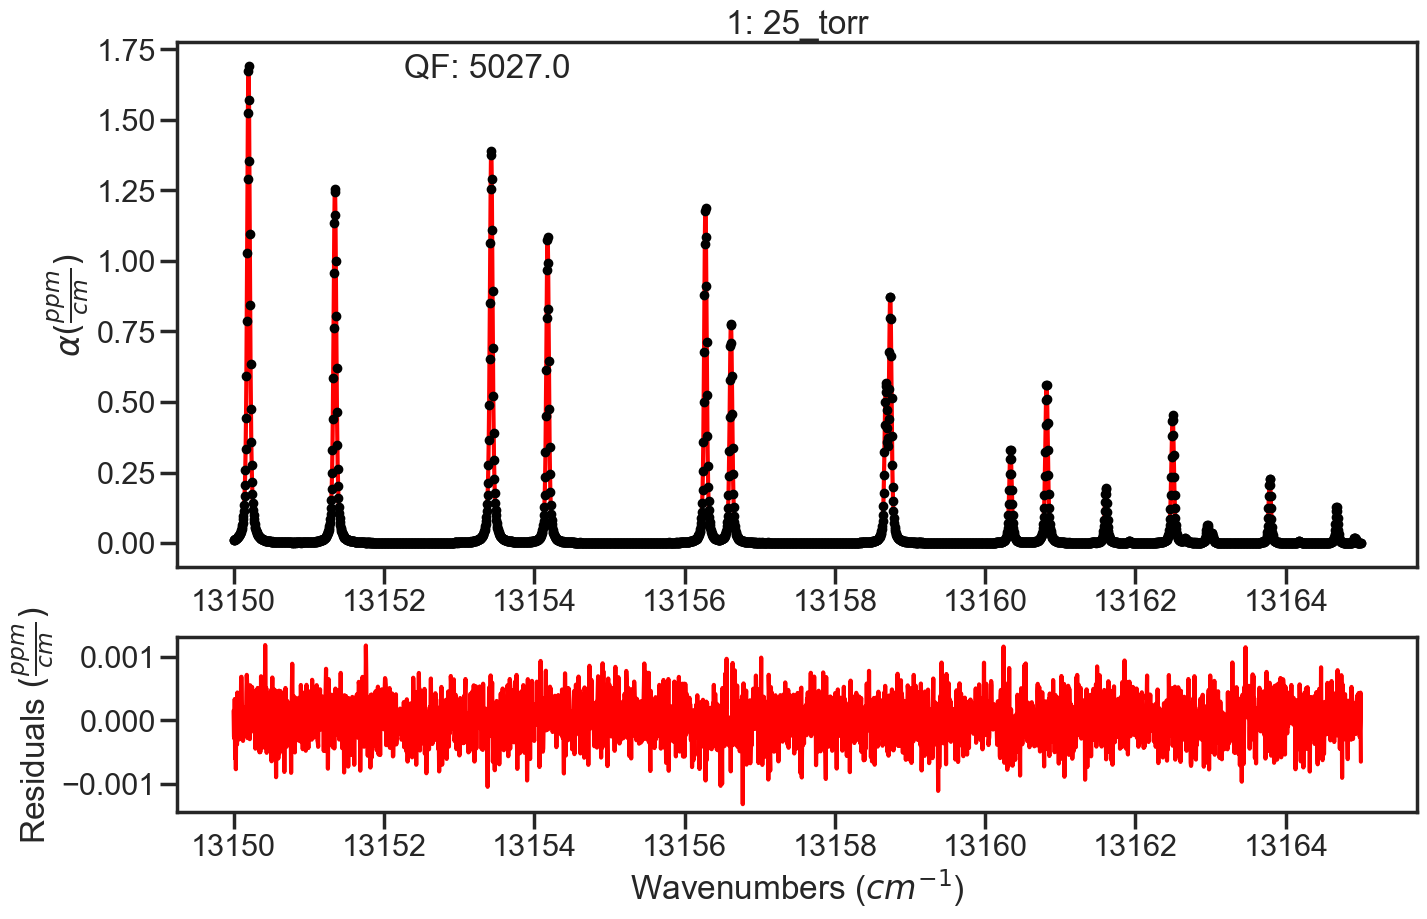

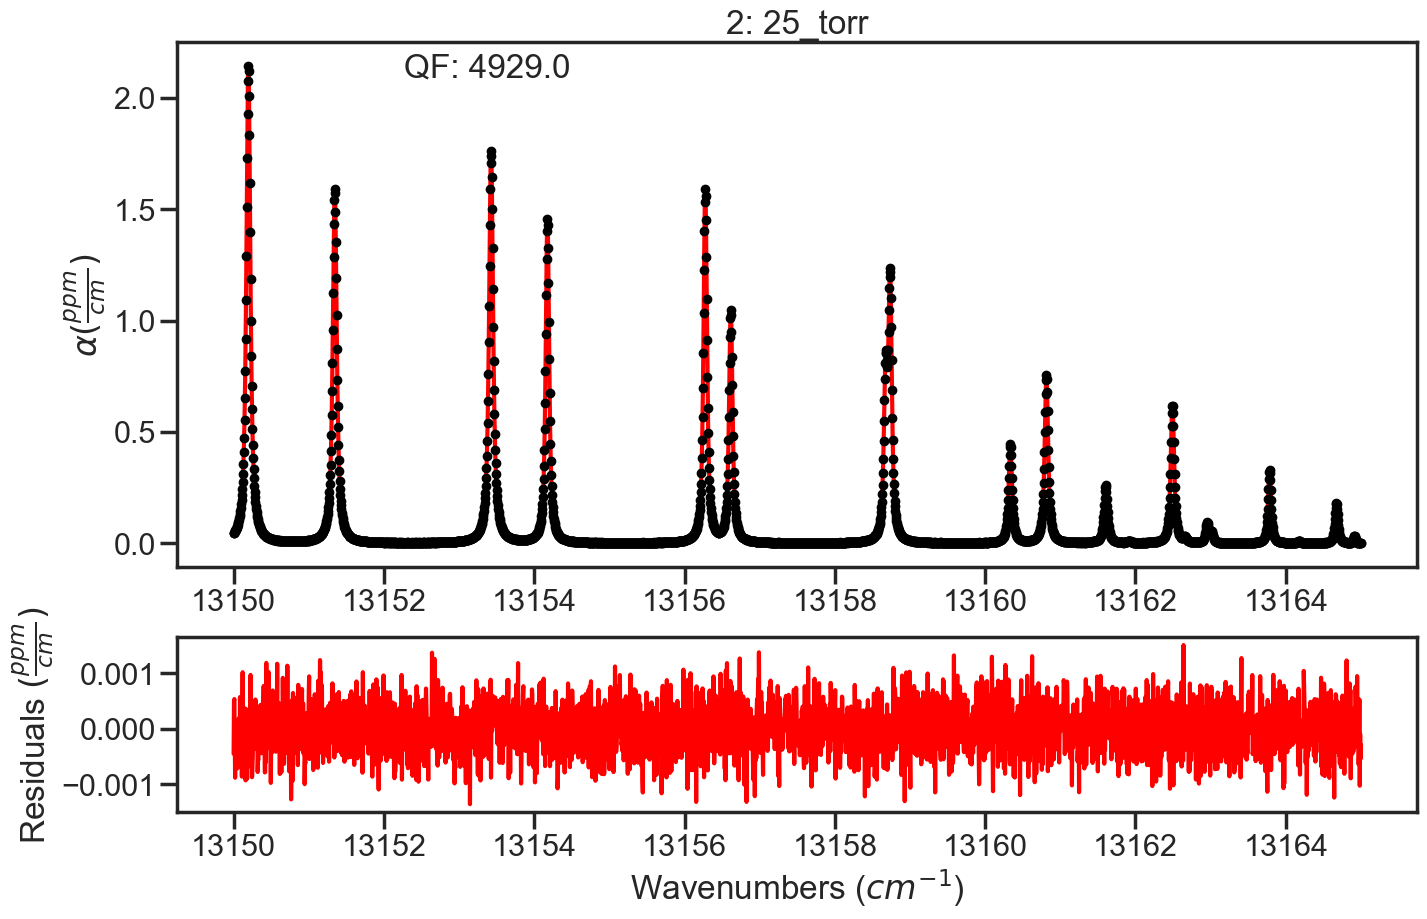

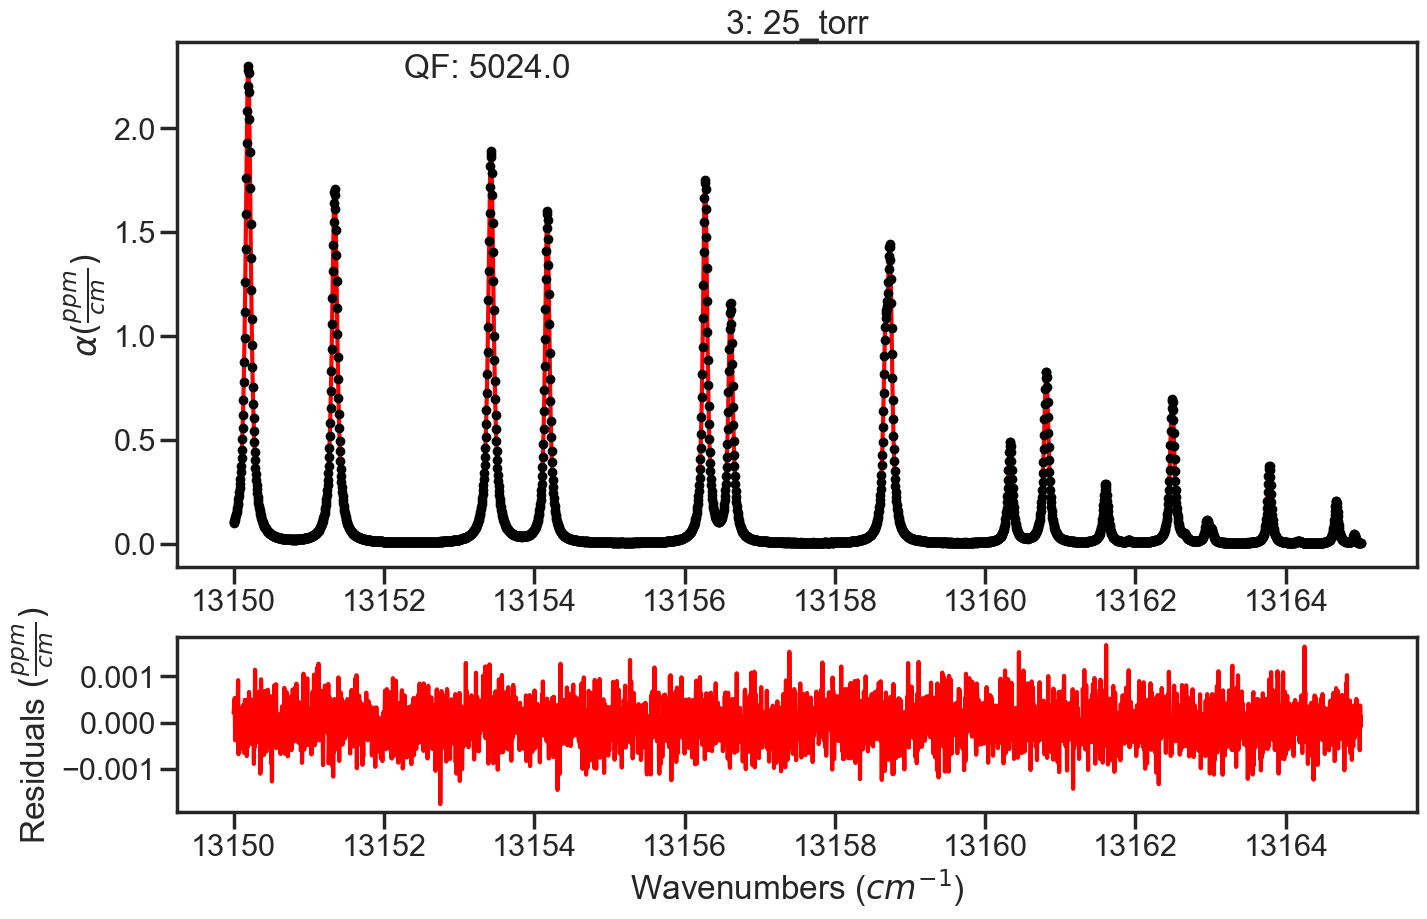

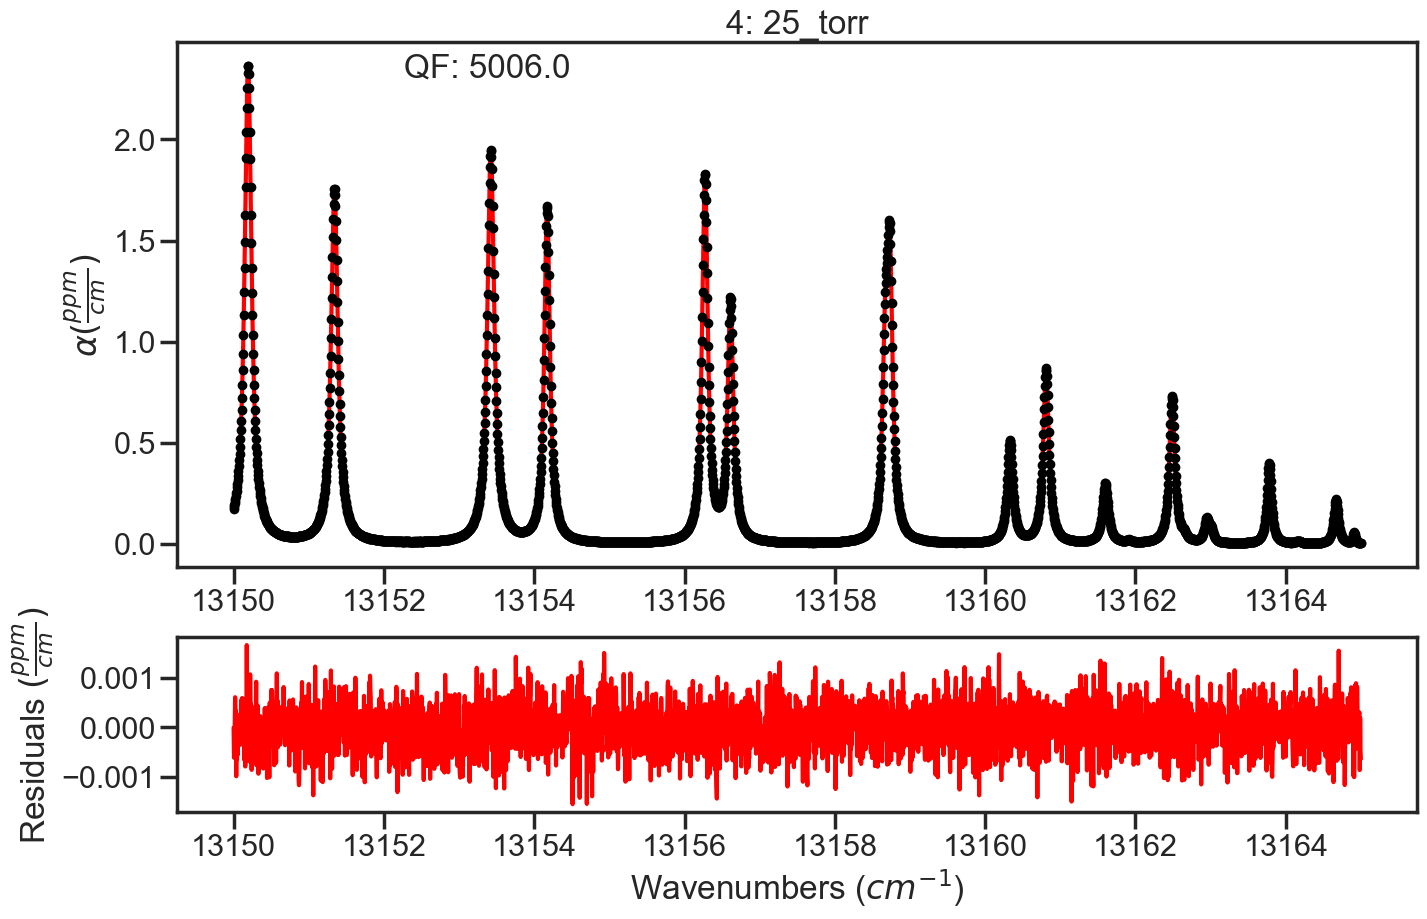

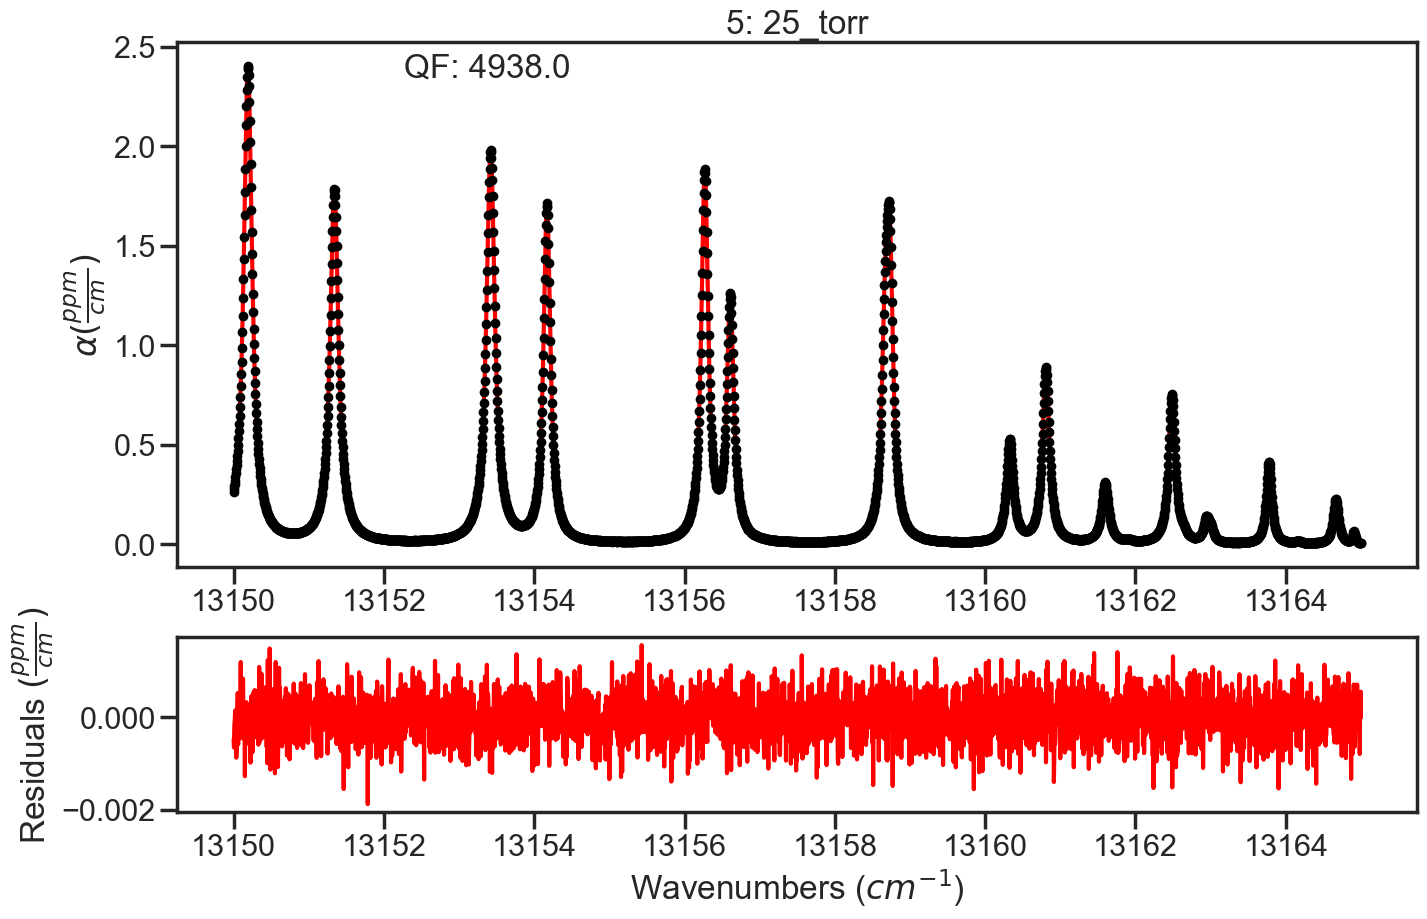

In [6]:
fit_data = MATS.Fit_DataSet(SPECTRA,'Baseline_LineList', 'Parameter_LineList', minimum_parameter_fit_intensity = Fit_Intensity/100, weight_spectra = False)


params = fit_data.generate_params()





result = fit_data.fit_data(params, wing_wavenumbers = 25, wing_method = 'wing_wavenumbers', 
                          method = 'least_squares') #least_squares is TRR and leastsq == LM
fit_data.residual_analysis(result, indv_resid_plot=True)

SPECTRA.generate_summary_file(save_file = True)
fit_data.update_params(result)
#SPECTRA.plot_model_residuals()